# ニューラルネットワーク
ニューラルネットワークを図で表すと以下のようになる。

```mermaid
flowchart LR
    subgraph layer0["0層：入力層"]
        direction TB
        x1((x₁))
        x2((x₂))
        x3((x₃))
    end

    subgraph layer1["1層：中間層（隠れ層）"]
        direction TB
        h1((h₁))
        h2((h₂))
        h3((h₃))
        h4((h₄))
    end

    subgraph layer2["2層：出力層"]
        direction TB
        y1((y₁))
        y2((y₂))
    end

    x1 --> h1 & h2 & h3 & h4
    x2 --> h1 & h2 & h3 & h4
    x3 --> h1 & h2 & h3 & h4

    h1 --> y1 & y2
    h2 --> y1 & y2
    h3 --> y1 & y2
    h4 --> y1 & y2

    classDef input fill:#dbeafe,stroke:#2563eb,color:#172554
    classDef hidden fill:#fef3c7,stroke:#d97706,color:#451a03
    classDef output fill:#dcfce7,stroke:#16a34a,color:#052e16
    class x1,x2,x3 input
    class h1,h2,h3,h4 hidden
    class y1,y2 output
    style layer0 fill:none,stroke:none
    style layer1 fill:none,stroke:none
    style layer2 fill:none,stroke:none
```

左の列を入力層、一番右の列を出力層、中間の列を中間層（隠れ層）と呼びます。

## 単一ニューロン

以下の図は単一のニューロンをグラフで図示しています。

```mermaid
flowchart LR
    bias((1)) -->|b| y((y))
    x1((x₁)) -->|w₁| y
    x2((x₂)) -->|w₂| y

    classDef input fill:#dbeafe,stroke:#2563eb,color:#172554
    classDef output fill:#dcfce7,stroke:#16a34a,color:#052e16
    class bias,x1,x2 input
    class y output
```

このニューロンの出力 $y$ は以下の式で表すことができます。

$$y = h(b + w_1x_1 + w_2x_2) \tag{1}$$

$$
h(x) =
\begin{cases}
0 & (x \leq 0) \\
1 & (x > 0)
\end{cases} \tag{2}
$$

式 (1) は、入力信号の総和が $h(x)$ という関数によって変換され、その変換された値が出力 $y$ になるということを意味します。そして式 (2) で表される $h(x)$ 関数は、入力が $0$ を超えたら $1$ を返し、そうでなければ $0$ を返します。

## 活性化関数

$h(x)$ のような関数を一般に活性化関数 (activation function) と呼びます。名前が意味するように、活性化関数は入力信号の総和がどのように活性化するかということを決定する役割があります。

式 (2) で表される活性化関数は、閾値を境にして出力が切り替わる関数で「ステップ関数」または「階段関数」と呼ばれます。

### ステップ関数の実装

In [5]:
import numpy as np


def step_function(x):
    y = x > 0
    return y.astype(int)

x = np.array([-1.0, 1.0, 2.0])
step_function(x)

array([0, 1, 1])

### ステップ関数のグラフ

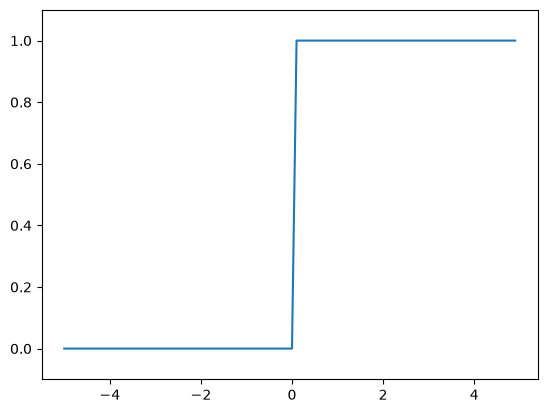

In [8]:
import matplotlib.pylab as plt
import numpy as np


def step_function(x):
    return np.array(x > 0, dtype=int)

x = np.arange(-5.0, 5.0, 0.1)
y = step_function(x)
plt.plot(x, y)
plt.ylim(-0.1, 1.1)
plt.show()

### シグモイド関数

ニューラルネットワークでよく用いられる活性化関数の一つは以下の式で表されるシグモイド関数です。

$$h(x) = \frac{1}{1 + \exp(-x)} \tag{3}$$

### シグモイド関数の実装

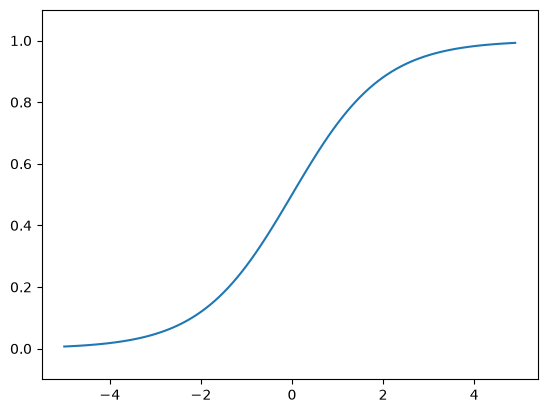

In [9]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

x = np.arange(-5.0, 5.0, 0.1)
y = sigmoid(x)
plt.plot(x, y)
plt.ylim(-0.1, 1.1)
plt.show()

### 非線形関数

ステップ関数とシグモイド関数の共通点はどちらも非線形関数という点です。ニューラルネットワークでは活性化関数に非線形関数を用いる必要があります。これは線形関数を用いると、どんなに層を深くしても、それと同じことを行う「隠れ層の無いネットワーク」が必ず存在するという事実に起因します。

### ReLU 関数

シグモイド関数はニューラルネットワークの歴史において古くから利用されてきましたが、最近では ReLU (Rectified Linear Unit) という関数が主に用いられます。ReLU は入力が $0$ を超えていれば、その入力をそのまま出力し、$0$ 以下ならば $0$ を出力する関数です。

$$
h(x) =
\begin{cases}
x & (x > 0) \\
0 & (x \leq 0)
\end{cases} \tag{4}
$$

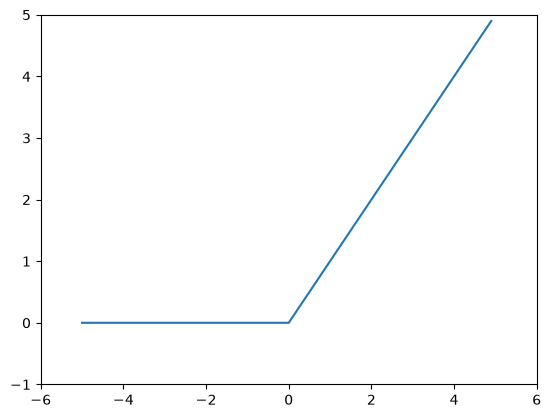

In [ ]:
def relu(x):
    return np.maximum(0, x)

x = np.arange(-5.0, 5.0, 0.1)
y = relu(x)
plt.plot(x, y)
plt.xlim(-6.0, 6.0)
plt.ylim(-1.0, 5.5)
plt.show()

## 多次元配列とニューラルネットワーク

以下のようなシンプルなニューラルネットワークを対象とします。このニューラルネットワークはバイアスと活性化関数を省略して、重みだけがあるものとします。

```mermaid
flowchart LR
    x1((x₁)) -->|1| y1((y₁))
    x2((x₂)) -->|2| y1
    x1 -->|3| y2((y₂))
    x2 -->|4| y2
    x1 -->|5| y3((y₃))
    x2 -->|6| y3

    classDef input fill:#dbeafe,stroke:#2563eb,color:#172554
    classDef output fill:#dcfce7,stroke:#16a34a,color:#052e16
    class x1,x2 input
    class y1,y2,y3 output
```

In [27]:
X = np.array([1, 2])
print(X.shape)
W = np.array([[1, 3, 5], [2, 4, 6]])
print(W)
print(W.shape)

Y = np.dot(X, W)
print(Y)

(2,)
[[1 3 5]
 [2 4 6]]
(2, 3)
[ 5 11 17]


### ３層ニューラルネットワークの実装

以下に示す３層ニューラルネットワークを対象として、その入力から出力への処理（フォワード方向への処理）を実装します。

```mermaid
flowchart LR
    bias((1)) --> h11((h₁⁽¹⁾)) & h12((h₂⁽¹⁾)) & h13((h₃⁽¹⁾))
    x1((x₁)) --> h11 & h12 & h13
    x2((x₂)) --> h11 & h12 & h13

    h11 --> h21((h₁⁽²⁾)) & h22((h₂⁽²⁾))
    h12 --> h21 & h22
    h13 --> h21 & h22

    h21 --> y1((y₁)) & y2((y₂))
    h22 --> y1 & y2

    classDef input fill:#dbeafe,stroke:#2563eb,color:#172554
    classDef hidden1 fill:#fef3c7,stroke:#d97706,color:#451a03
    classDef hidden2 fill:#fce7f3,stroke:#db2777,color:#500724
    classDef output fill:#dcfce7,stroke:#16a34a,color:#052e16
    class bias,x1,x2 input
    class h11,h12,h13 hidden1
    class h21,h22 hidden2
    class y1,y2 output
```